In [1]:
import pandas as pd
import sqlite3
import db_mgmt as mgmt
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from seaborn import axes_style
import visuals as v



In [2]:
flex_path = 'outputs/flex_ON/canoe_ref.sqlite'
flex_db = mgmt.sqlite_to_dfs(flex_path)

inflex_path = 'outputs/inflex_ON/canoe_ref.sqlite'
inflex_db = mgmt.sqlite_to_dfs(inflex_path)

scenarios = {"flex":flex_db, "inflex": inflex_db}

vg = pd.read_csv('dbs/vehicle_grouping.csv')

## What technologies meet each demand type?

In [3]:
data = flex_db.copy()
demands = data['Demand'].copy()
demand_comm = demands.loc[demands['commodity'].str.contains('T_D_'),'commodity'].unique()

df = data['Efficiency'].copy()
vg_demand = {}
for demand in demand_comm: 
    # print(f'\n\nDemand: {demand}: {df.loc[df['output_comm']==demand, 'tech'].unique()}')
    vg_demand[demand] = df.loc[df['output_comm']==demand, 'tech'].unique()


## Zooming into the car capacity vs demand

    vintage     tech_label  capacity
0      2010         DSL_EX      18.0
1      2010         GSL_EX     593.0
2      2015      BEV150_EX       4.0
3      2015         DSL_EX      40.0
4      2015         GSL_EX    1357.0
5      2015     GSL_HEV_EX      31.0
6      2015  GSL_PHEV35_EX       3.0
7      2020      BEV150_EX      37.0
8      2020         DSL_EX       4.0
9      2020         GSL_EX    1658.0
10     2020     GSL_HEV_EX      48.0
11     2020  GSL_PHEV35_EX      23.0


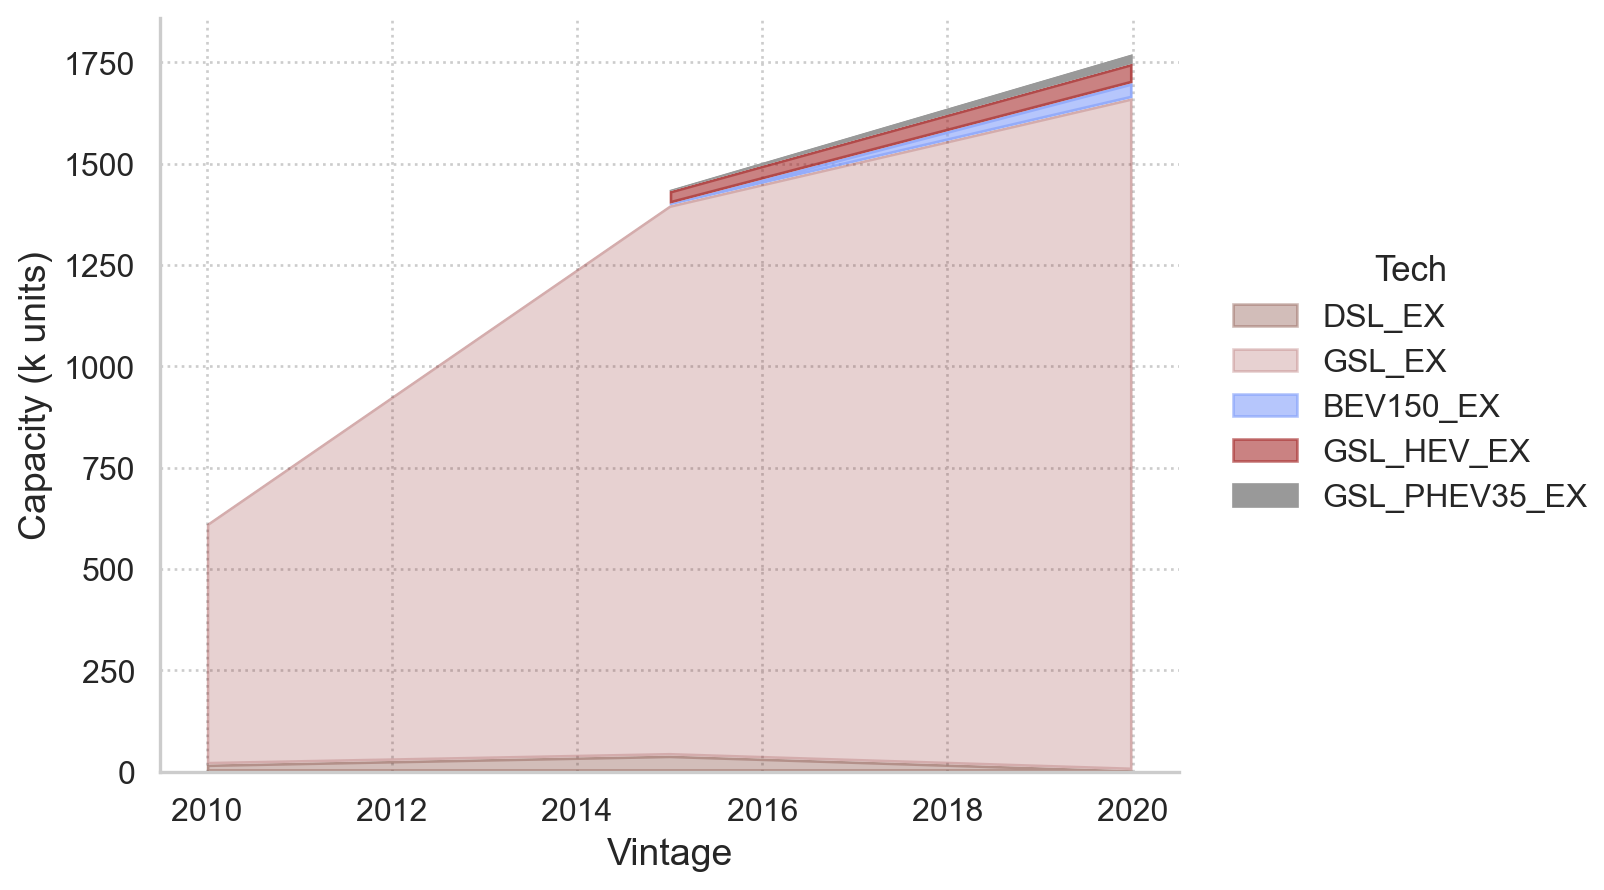

In [4]:
# Existing Capacity

comm = 'T_D_pkm_ldv_c'
vg_demand[comm] 
df_ex = data['ExistingCapacity'].copy()
df_ex = df_ex.loc[df_ex['tech'].isin(vg_demand[comm])]
df_ex = df_ex.groupby(['vintage','tech'])['capacity'].sum().reset_index()



v.area_plot(df_ex, x='vintage', y='capacity', hue='tech', ylabel='Capacity (k units)')

   period commodity_label      demand
0    2025   T_D_pkm_ldv_c  131.348453
1    2030   T_D_pkm_ldv_c  146.205585
2    2035   T_D_pkm_ldv_c  157.486848
3    2040   T_D_pkm_ldv_c  168.832670
4    2045   T_D_pkm_ldv_c  180.011737
5    2050   T_D_pkm_ldv_c  192.755816


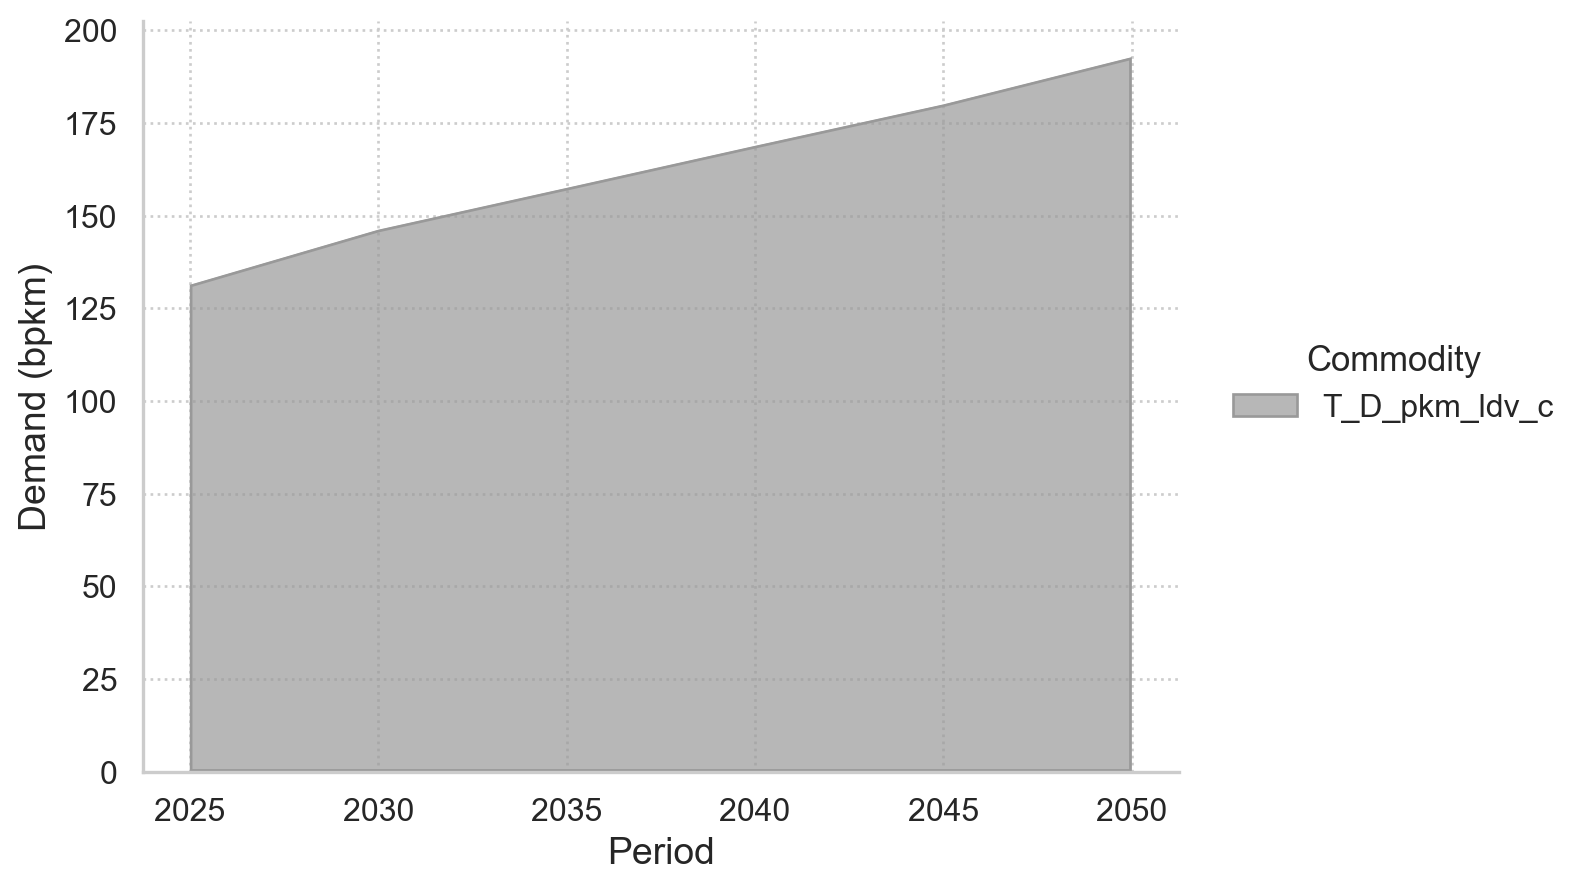

In [5]:
df = data['Demand'].copy()
df = df.loc[df['commodity']==comm]
df = df[['period', 'demand', 'units', 'commodity']]

v.area_plot(df, x='period', y='demand', hue='commodity', ylabel='Demand (bpkm)')




In [6]:
df = data['CapacityToActivity'].copy()
df = df.loc[df['tech'].str.contains('LDV_C_')]
df['c2a'].mean(),df['c2a'].max(), df['c2a'].min(), df['c2a'].std()

(np.float64(1.3), np.float64(1.3), np.float64(1.3), np.float64(0.0))

    period     tech_label     capacity
0     2025         BEV150    17.752835
1     2025      BEV150_EX    37.752344
2     2025         BEV200    35.505669
3     2025         BEV300    53.258504
4     2025         BEV400    71.011338
..     ...            ...          ...
91    2050     GSL_HEV_EX     0.246091
92    2050     GSL_PHEV35    44.902449
93    2050  GSL_PHEV35_EX     0.105525
94    2050     GSL_PHEV50     0.000933
95    2050     H2_FCEV400  1567.594766

[96 rows x 3 columns]


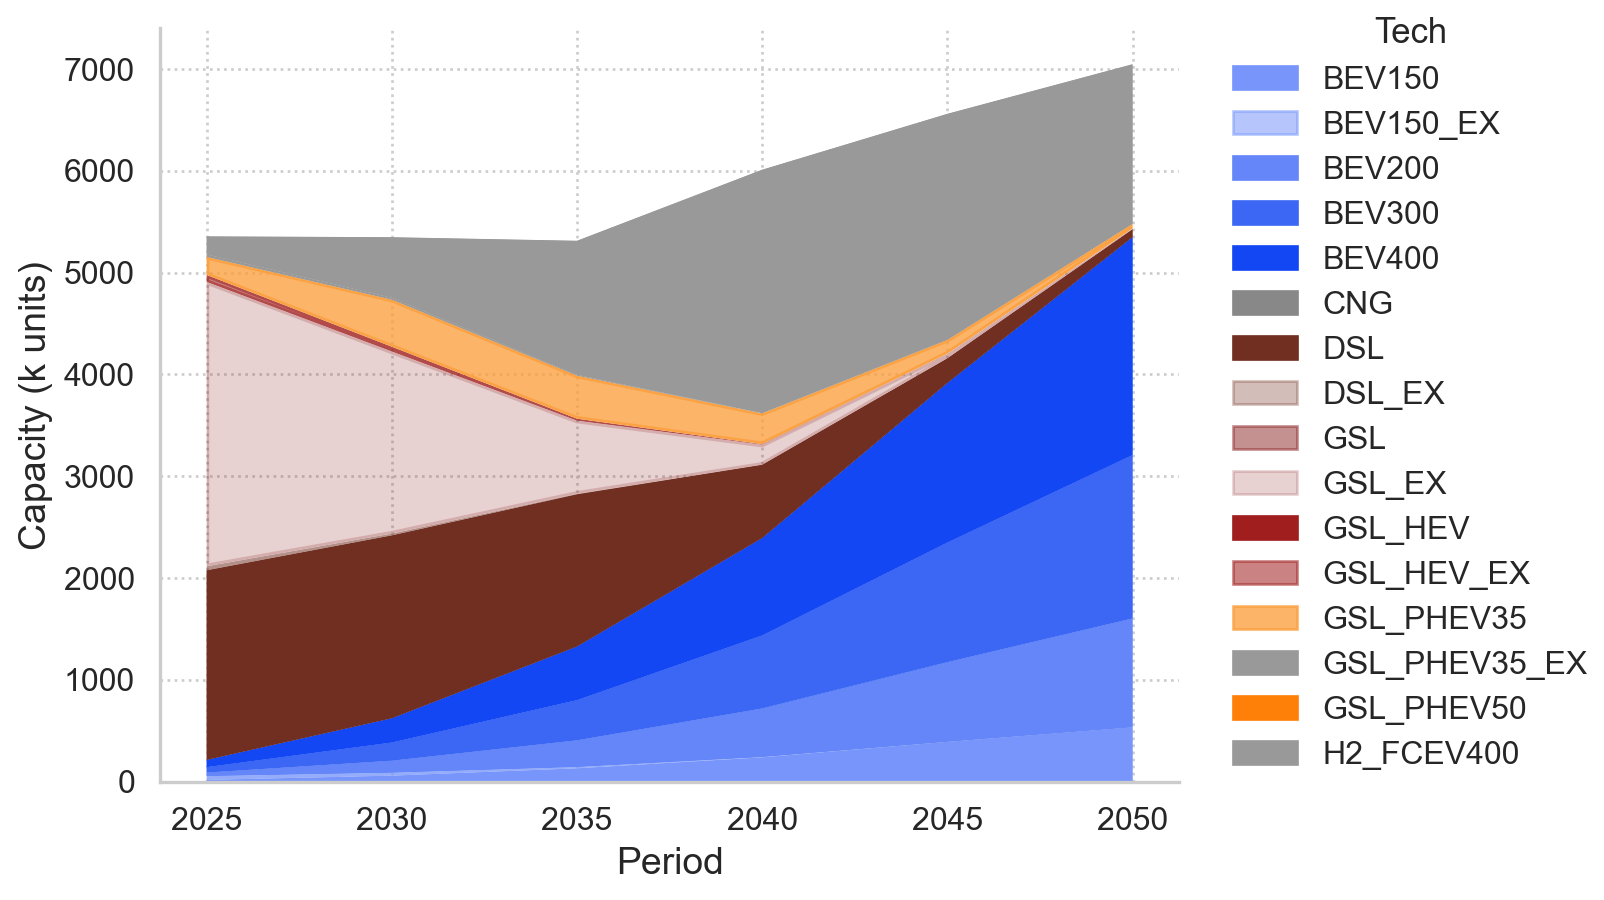

In [7]:
df_net = data['OutputNetCapacity'].copy()
df_net = df_net.loc[df_net['tech'].str.contains('LDV_C_')]
df_net = df_net[['period', 'capacity', 'tech']]

v.area_plot(df_net, x='period', y='capacity', hue='tech', ylabel='Capacity (k units)')



    vintage  tech_label   capacity
0      2025      BEV150  17.873928
1      2025      BEV200  35.747855
2      2025      BEV300  53.621783
3      2025      BEV400  71.495711
4      2025         CNG   0.000168
..      ...         ...        ...
61     2050         GSL   0.000027
62     2050     GSL_HEV   0.000063
63     2050  GSL_PHEV35   0.950720
64     2050  GSL_PHEV50   0.000087
65     2050  H2_FCEV400  33.190886

[66 rows x 3 columns]


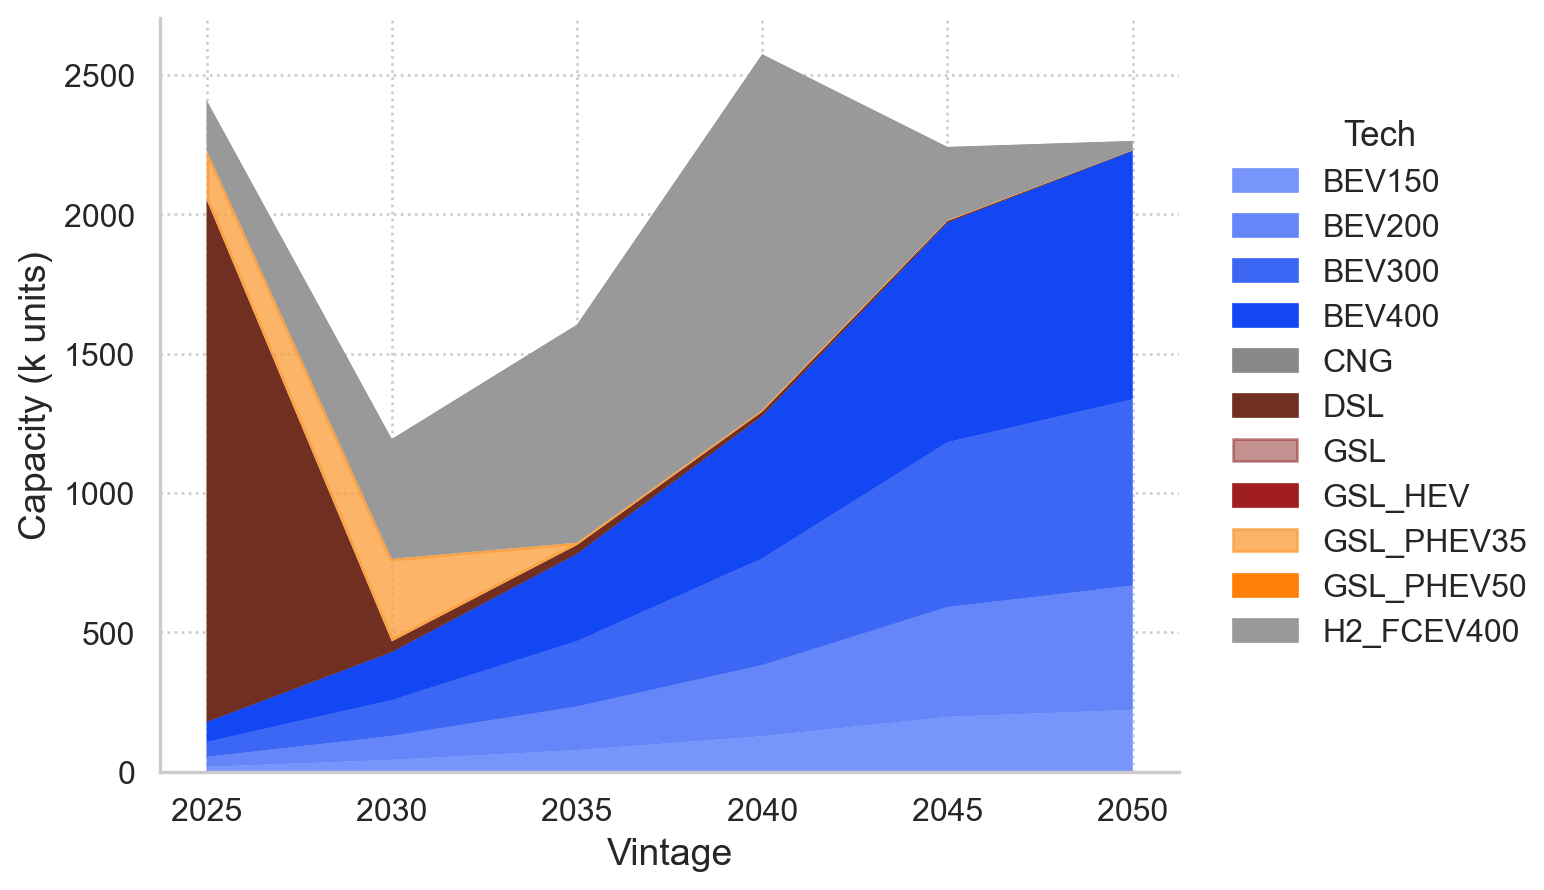

In [8]:
df_built = data['OutputBuiltCapacity'].copy()
df_built = df_built.loc[df_built['tech'].str.contains('LDV_C_')]
df_built = df_built[['vintage', 'capacity', 'tech']]

v.area_plot(df_built, x='vintage', y='capacity', hue='tech', ylabel='Capacity (k units)')

     period                   tech     capacity
0      2010         T_LDV_C_DSL_EX    18.000000
1      2010         T_LDV_C_GSL_EX   593.000000
2      2015      T_LDV_C_BEV150_EX     4.000000
3      2015         T_LDV_C_DSL_EX    40.000000
4      2015         T_LDV_C_GSL_EX  1357.000000
..      ...                    ...          ...
103    2050      T_LDV_C_GSL_HEV_N     0.000273
104    2050          T_LDV_C_GSL_N     0.000077
105    2050  T_LDV_C_GSL_PHEV35_EX     0.105525
106    2050   T_LDV_C_GSL_PHEV35_N    50.398550
107    2050   T_LDV_C_GSL_PHEV50_N     0.001372

[108 rows x 3 columns]
     period     tech_label     capacity
0      2010         DSL_EX    18.000000
1      2010         GSL_EX   593.000000
2      2015      BEV150_EX     4.000000
3      2015         DSL_EX    40.000000
4      2015         GSL_EX  1357.000000
..      ...            ...          ...
103    2050     GSL_HEV_EX     0.246091
104    2050     GSL_PHEV35    50.398550
105    2050  GSL_PHEV35_EX     0.105525


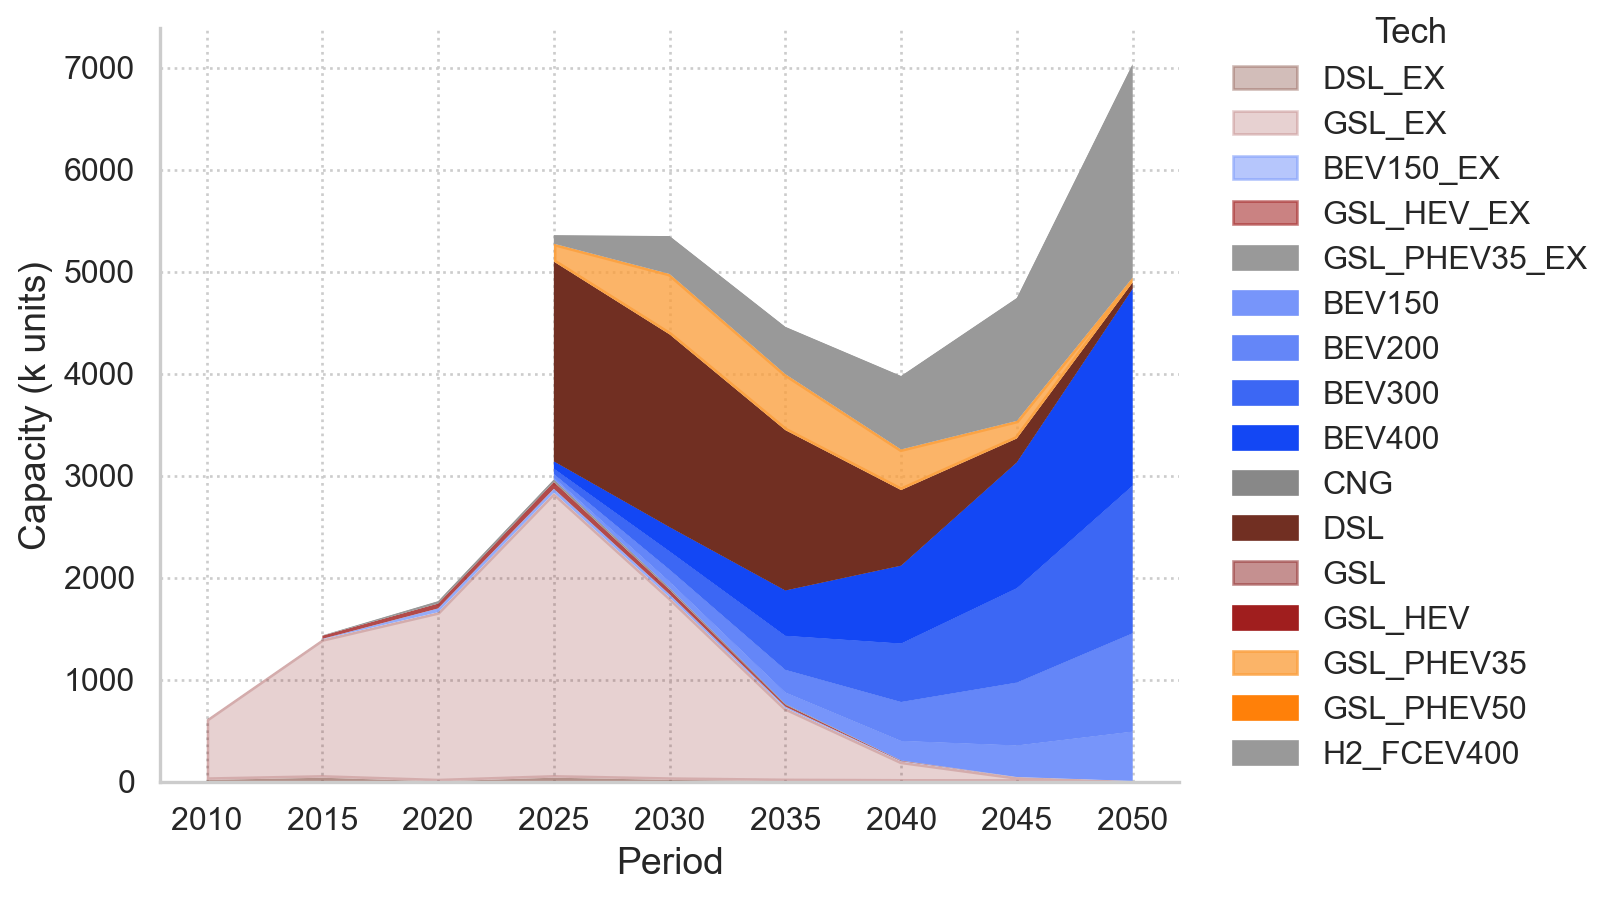

In [18]:
df = df_ex.copy()
df['period'] = df['vintage']
df = df[['period', 'capacity', 'tech']]
df = pd.concat([df, df_net], ignore_index=True)

df = df.groupby(['period', 'tech'])['capacity'].sum().reset_index()
print(df)

v.area_plot(df, x='period', y='capacity', hue='tech', ylabel='Capacity (k units)')


['T_LDV_LTP_GSL_PHEV35_N', 'T_LDV_C_BEV200_N', 'T_LDV_LTP_GSL_PHEV35_EX', 'T_LDV_C_CNG_N', 'T_LDV_LTP_GSL_EX', 'T_LDV_C_GSL_HEV_EX', 'T_LDV_C_DSL_N', 'T_LDV_C_BEV300_N', 'T_LDV_C_BEV150_EX', 'T_LDV_LTP_BEV300_EX', 'T_LDV_LTP_CNG_N', 'T_LDV_C_BEV400_N', 'T_LDV_C_GSL_HEV_N', 'T_LDV_LTP_DSL_N', 'T_LDV_LTP_GSL_PHEV50_N', 'T_LDV_LTP_FCEV400_N', 'T_LDV_C_GSL_PHEV35_N', 'T_LDV_C_GSL_N', 'T_LDV_LTP_BEV200_N', 'T_LDV_LTP_GSL_HEV_EX', 'T_LDV_LTP_BEV300_N', 'T_LDV_LTP_BEV150_N', 'T_LDV_C_BEV150_N', 'T_LDV_C_DSL_EX', 'T_LDV_LTP_DSL_EX', 'T_LDV_C_GSL_PHEV35_EX', 'T_LDV_LTP_BEV400_N', 'T_LDV_C_GSL_EX', 'T_LDV_C_FCEV400_N', 'T_LDV_C_GSL_PHEV50_N', 'T_LDV_LTP_GSL_HEV_N', 'T_LDV_LTP_GSL_N']
     period                     tech     capacity
0      2025        T_LDV_C_BEV150_EX    37.752344
1      2025         T_LDV_C_BEV150_N    17.752832
2      2025         T_LDV_C_BEV200_N    35.505664
3      2025         T_LDV_C_BEV300_N    53.258496
4      2025         T_LDV_C_BEV400_N    71.011328
..      ...      

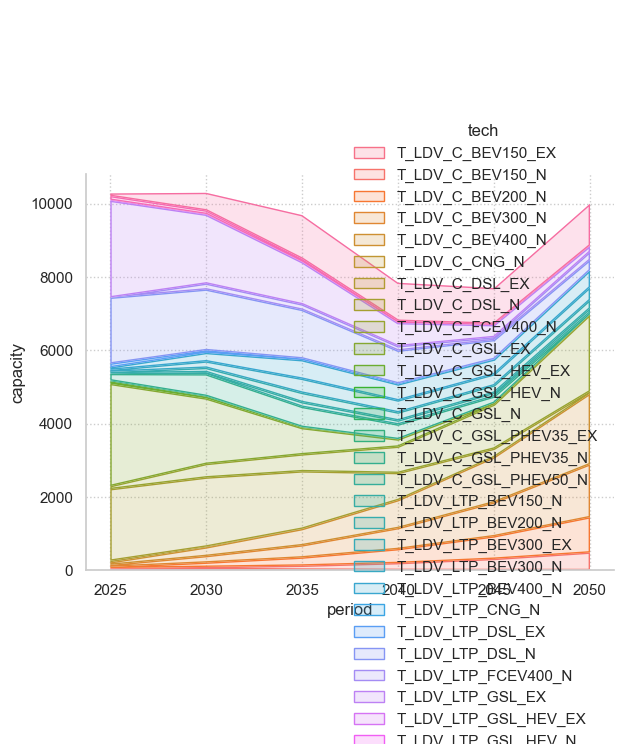

In [22]:
ldv = list(set(vg.loc[(vg['output_comm']=='T_D_pkm_ldv_c') | (vg['output_comm']=='T_D_pkm_ldv_t'), 'tech'].tolist()))
print(ldv)
df_ex = flex_db['ExistingCapacity'].copy()
df_new = flex_db['OutputBuiltCapacity'].copy()
df_net = flex_db['OutputNetCapacity'].copy()

df_ex = df_ex.loc[df_ex['tech'].isin(ldv)]
df_new = df_new.loc[df_new['tech'].isin(ldv)]
df_net = df_net.loc[df_net['tech'].isin(ldv)]


# df = pd.concat([df_ex, df_new], ignore_index=True)
df = df_net.copy()
df = df.groupby(['period', 'tech'])['capacity'].sum().reset_index()
print(df)




theme_dict = {
    **axes_style("whitegrid"),
    "grid.linestyle": ":",
    "legend.frameon": False,      # remove legend box
    "axes.spines.right": False,   # despine
    "axes.spines.top": False,
}



fig = (
    so.Plot(data=df, x='period', y='capacity', color='tech')
    .add(so.Area(), so.Stack())
    .theme(theme_dict)
    .layout(engine="tight")
)


fig.save('figures/ldv_capacity_by_vintage.png', dpi=300)
fig.show()

In [41]:
df = flex_db['OutputNetCapacity'] 

df = df.groupby(['period', 'tech'])['capacity'].sum().reset_index()

df.loc[df['tech'].str.contains('LDV_C_', case=False)].groupby('period')['capacity'].sum().reset_index()

,period,capacity
0,2025,5356.711214
1,2030,5348.231762
2,2035,4458.719647
3,2040,3976.860246
4,2045,4741.270478
5,2050,7032.805900


In [42]:
vg = pd.read_csv('dbs/vehicle_grouping.csv')
cars = vg.loc[vg['mode']=='Cars']
modes = vg['mode'].unique()
theme_dict = {
    **axes_style("whitegrid"),
    "grid.linestyle": ":",
    "legend.frameon": False,      # remove legend box
    "axes.spines.right": False,   # despine
    "axes.spines.top": False,
}

all_tech_colors = {'BEV150': '#14ff4e',
 'BEV200': "#54ff7e",
 'BEV300': "#b7ffc9",
 'BEV400': "#87fba3",
 'CNG': "#bd6767",
 'DSL': '#8c564b',
 'FCEV400': '#e377c2',
 'GSL_HEV': '#7f7f7f',
 'GSL': "#000000",
 'GSL_PHEV35': "#716E6EC4",
 'GSL_PHEV50': '#bf2f40'}


In [45]:
vg_ti = vg.set_index('tech')


all_tech_colors = {'BEV150': '#14ff4e',
 'BEV200': "#54ff7e",
 'BEV300': "#b7ffc9",
 'BEV400': "#87fba3",
 'CNG': "#bd6767",
 'DSL': '#8c564b',
 'FCEV400': '#e377c2',
 'GSL_HEV': '#7f7f7f',
 'GSL': "#000000",
 'GSL_PHEV35': "#716E6EC4",
 'GSL_PHEV50': '#bf2f40'}



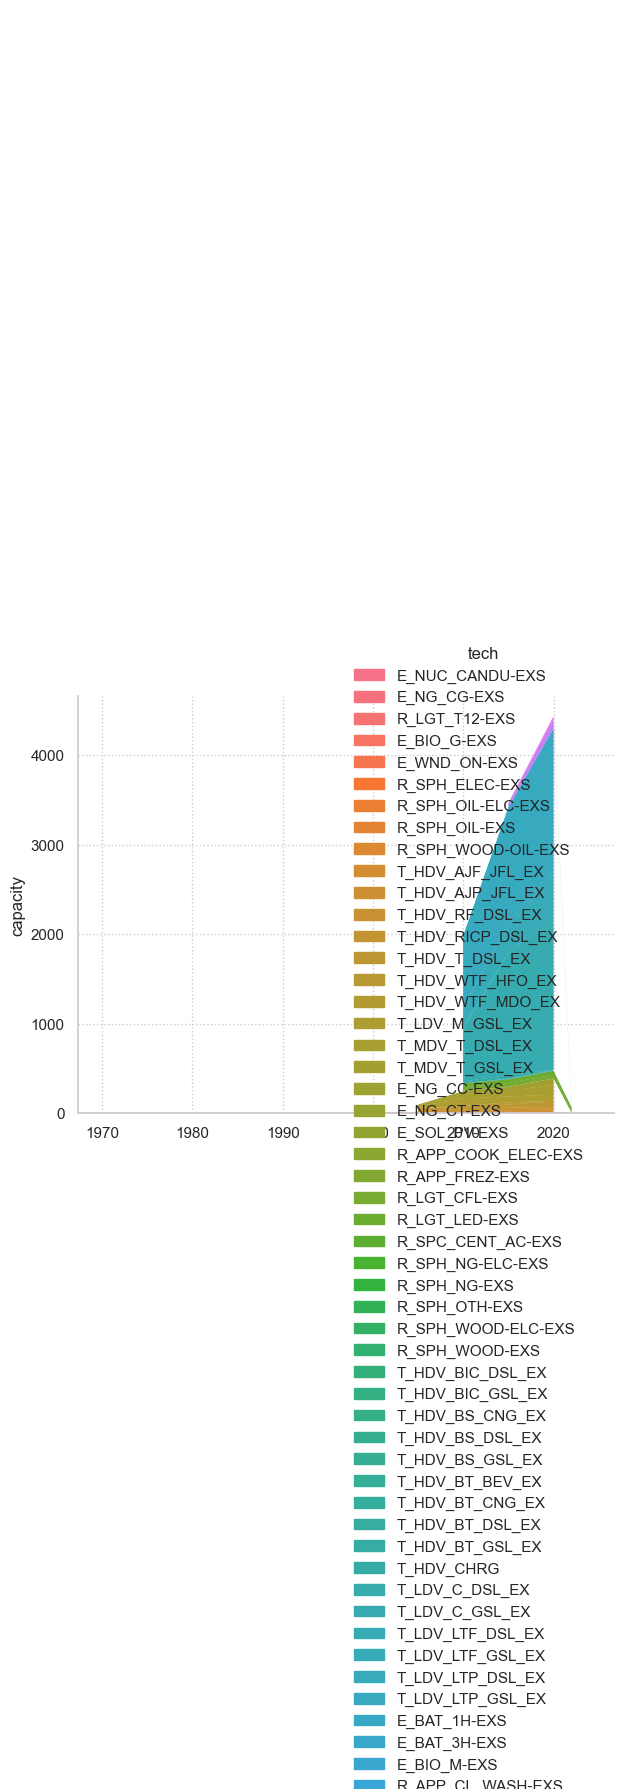

In [46]:
# flex non ZEV

db = flex_db.copy()
df_ex = db['ExistingCapacity'].copy()
df_new = db['OutputBuiltCapacity'].copy()
df_net = db['OutputNetCapacity'].copy()
sub_dfs = {'ExistingCapacity': df_ex, 'OutputBuiltCapacity': df_new, 'OutputNetCapacity': df_net}


# Plotting existing capacity
df = df_ex.copy()
df = df.groupby(['vintage', 'tech'])['capacity'].sum().reset_index()


fig = (
    so.Plot(data=df, x='vintage', y='capacity', color='tech')
    .add(so.Area(alpha=1), so.Agg(), so.Stack())
    .label(y=f'capacity', x='', title='')
    .theme(theme_dict)
    .layout(engine="tight")
    
)



fig.show()



In [21]:
df = inflex_db['OutputBuiltCapacity']

df = df.loc[df['sector']=='transportation'].copy()

df = df.groupby(['tech','vintage'], as_index=False)['capacity'].sum()
df = df.loc[df['tech'].isin(cars['tech'])]





In [5]:
tech = [item.split('_') for item in df.tech.unique()]
tech_rename = {item: item.split('T_LDV_C_')[1].split('_N')[0] for item in df.tech.unique()}
tech_rename


df['tech'] = df['tech'].map(tech_rename)
tech_cars = df.loc[df['capacity'] >= 1, 'tech'].unique()
df = df.loc[df['tech'].isin(tech_cars)]

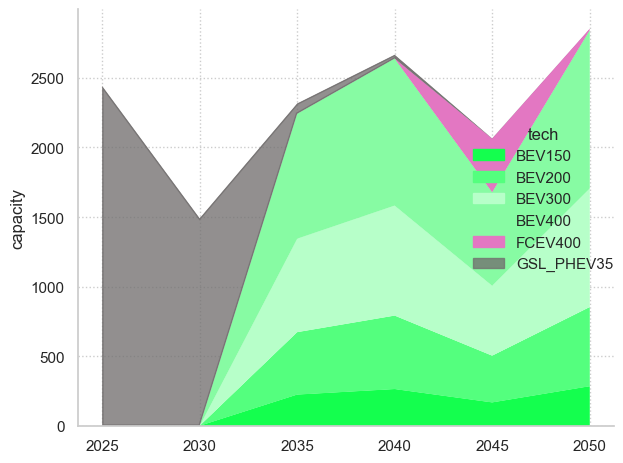

In [ ]:


all_tech_colors = {'BEV150': '#14ff4e',
 'BEV200': "#54ff7e",
 'BEV300': "#b7ffc9",
 'BEV400': "#87fba3",
 'CNG': "#bd6767",
 'DSL': '#8c564b',
 'FCEV400': '#e377c2',
 'GSL_HEV': '#7f7f7f',
 'GSL': "#000000",
 'GSL_PHEV35': "#716E6EC4",
 'GSL_PHEV50': '#bf2f40'}


tech_colors = {k: all_tech_colors[k] for k in df.tech.unique()} 

theme_dict = {
    **axes_style("whitegrid"),
    "grid.linestyle": ":",
    "legend.frameon": False,      # remove legend box
    "axes.spines.right": False,   # despine
    "axes.spines.top": False,
}


fig = (
    so.Plot(data=df, x='vintage', y='capacity', color='tech')
    .add(so.Area(alpha=1), so.Agg(), so.Stack())
    .label(y=f'capacity', x='', title='')
    .scale(color=tech_colors)
    .theme(theme_dict)
    .layout(engine="tight")
    
)



fig.save('analysis/figures/inflex_built_cap_cars.png', dpi=300)
fig.show()



In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so 
import sqlite3
import re
from seaborn import axes_style
import db_mgmt as mgmt 






In [65]:
vehicle_grouping = pd.read_csv('../CANOE_ref/dbs/vehicle_grouping.csv')
demand_dict = pd.read_csv("../CANOE_ref/dbs/demand_dict.csv")
# ZEV vs NON ZEV
df_compare = {}

# Status quo - Flex
modes = ['HDV', 'LDV']
flexibility = ['inflex_ON', 'flex_ON']  
for f in flexibility:
    for mode in modes:
        db_path = f'outputs/{f}/canoe_ref.sqlite'
        data = mgmt.sqlite_to_dfs(db_path)

        ex_df = data['ExistingCapacity'].copy()
        new_df = data['OutputBuiltCapacity'].copy()

        df = new_df.loc[new_df['tech'].isin(vehicle_grouping['tech'])]


        # add vehicle_grouping columns to df by tech (preserves existing df and appends columns)
        cols_to_add = ['mode', 'unit', 'zev_class', 'fuel_type_1', 'fuel_type_2', 'vehicle_type', 'group_name', 'demand_type']
        df = df.merge(vehicle_grouping[['tech'] + cols_to_add], on='tech', how='left')

        # optional: report any techs that didn't get a mapping
        missing = df.loc[df[cols_to_add].isnull().any(axis=1), 'tech'].unique()
        if len(missing):
            print(f"Warning: {len(missing)} tech(s) missing mapping:", missing)

        DF = df[['tech','vintage', 'mode', 'vehicle_type', 'fuel_type_1', 'fuel_type_2', 'zev_class', 'unit', 'capacity', 'group_name', 'demand_type']].copy()

        df = DF.loc[(DF['group_name']==f'{mode}')&(DF['unit']=='k units'), ['fuel_type_1', 'capacity', 'vintage', 'tech']].copy()
        df.fuel_type_1.unique()
        df_compare[f'{mode}_{f}'] = df.copy()


In [66]:
df_compare.keys()

dict_keys(['HDV_inflex_ON', 'LDV_inflex_ON', 'HDV_flex_ON', 'LDV_flex_ON'])

In [151]:
modes = ['HDV', 'LDV']
flexibility = ['flex_ON', 'inflex_ON']
for mode in modes: 
    print(f'\n{mode} - Flex to Inflex Built Capacity Difference by Fuel Type\n')
    flex = df_compare[f'{mode}_flex_ON'].copy()
    inflex = df_compare[f'{mode}_inflex_ON'].copy()
    flex = flex.groupby(['fuel_type_1', 'vintage'])['capacity'].sum()
    inflex = inflex.groupby(['fuel_type_1', 'vintage'])['capacity'].sum()
    comparison = pd.concat([flex, inflex], axis=1)
    comparison.columns = [f'{mode}_flex_capacity', f'{mode}_inflex_capacity']
    comparison['capacity_diff'] = comparison[f'{mode}_inflex_capacity'] - comparison[f'{mode}_flex_capacity']
    # comparison.to_csv(f'analysis/{mode}_flex_vs_inflex_built_capacity.csv')
    comparison = comparison.groupby('fuel_type_1')['capacity_diff'].sum().reset_index()
    print(comparison)


HDV - Flex to Inflex Built Capacity Difference by Fuel Type

  fuel_type_1  capacity_diff
0         cng       0.000000
1         dsl     -74.374717
2         elc     -40.565312
3         gsl       0.000000
4          h2     107.538895

LDV - Flex to Inflex Built Capacity Difference by Fuel Type

  fuel_type_1  capacity_diff
0         cng       0.004449
1         dsl      -0.000164
2         elc  -10353.883287
3         gsl    9921.189858
4          h2     348.735978


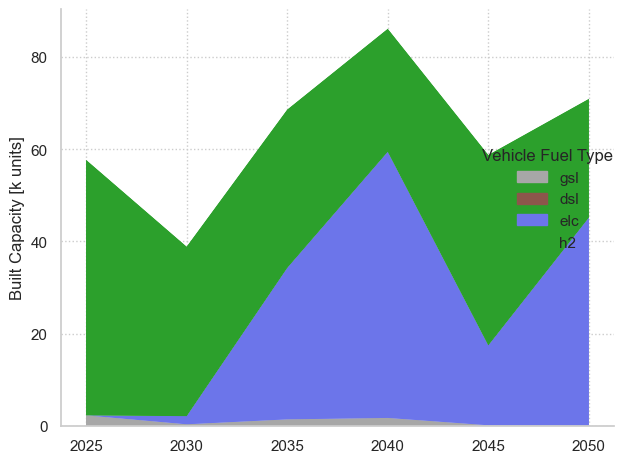

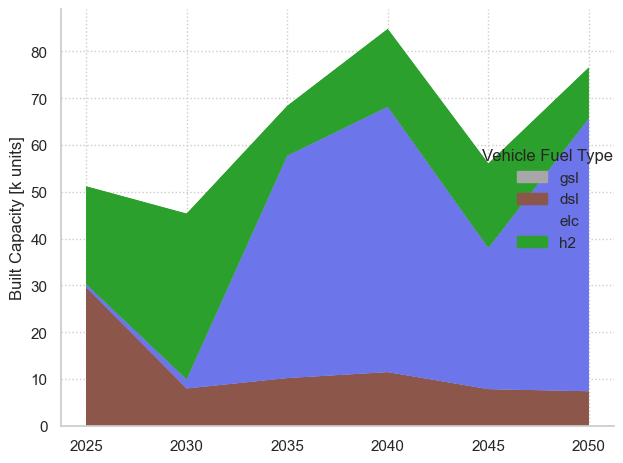

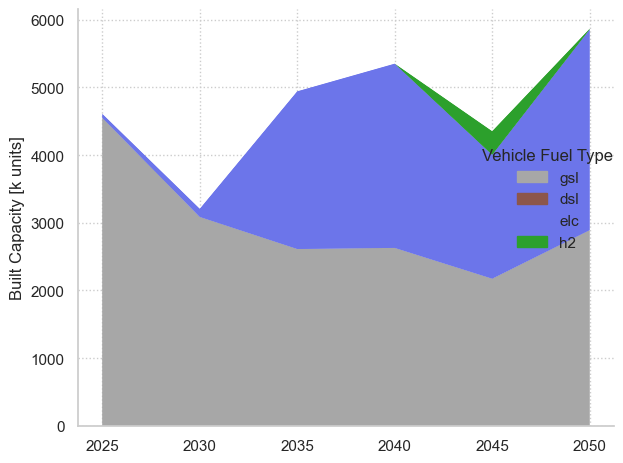

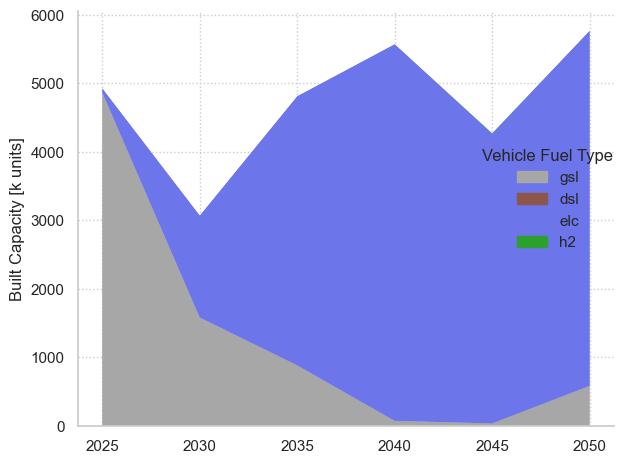

In [145]:
for mode in modes:
    for flex in flexibility:
        df = df_compare[f'{mode}_{flex}'].copy()
        df = df.groupby(['fuel_type_1', 'vintage'])['capacity'].sum().reset_index()
        # df['capacity'] /= 1000 # convert to M units
        theme_dict = {
            **axes_style("whitegrid"),
            "grid.linestyle": ":",
            "legend.frameon": False,      # remove legend box
            "axes.spines.right": False,   # despine
            "axes.spines.top": False,
        }

        order = ['gsl', 'dsl', 'elc', 'h2']
        color_map = {'gsl': "#A7A7A7", 'elc': "#6c75ea", 'dsl': "#8c564b", 'h2': "#2ca02c"}


        df["fuel_type_1"] = pd.Categorical(df["fuel_type_1"], categories=order, ordered=True)
        df = df.sort_values('fuel_type_1')
        unit = 'k units'

        fig = (
            so.Plot(data=df, x='vintage', y='capacity', color='fuel_type_1')
            .add(so.Area(alpha=1), so.Agg(), so.Stack())
            .scale(color=so.Nominal(order=order, values=color_map))
            .label(y=f'Built Capacity [{unit}]', x='', title='', color='Vehicle Fuel Type')
            .theme(theme_dict)
            .layout(engine="tight")
        )

        fig.save(f'analysis/figures/{mode}_BuiltCap_{flex}.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
        fig.show()

In [146]:
df_compare_costs = {}

# Status quo - Flex
flexibility = ['inflex_ON', 'flex_ON']  
for f in flexibility:
    db_path = f'outputs/{f}/canoe_ref.sqlite'
    data = mgmt.sqlite_to_dfs(db_path)
    df = data['OutputCost'].copy()
    df['TotalCost'] = df['d_invest'] + df['d_fixed'] + df['d_var'] + df['d_emiss']
    df_compare_costs[f] = df.copy()



In [147]:
compare_costs = pd.DataFrame()
for f in flexibility:
    df = df_compare_costs[f].copy()
    df = df.groupby(['sector', 'period'])['TotalCost'].sum().reset_index()
    df.rename(columns={'TotalCost': f'TotalCost_{f}'}, inplace=True)
    compare_costs = compare_costs.merge(df, on=['sector', 'period'], how='outer') if not compare_costs.empty else df.copy()

compare_costs['CostDiff'] = compare_costs['TotalCost_flex_ON'] - compare_costs['TotalCost_inflex_ON']


In [148]:
compare_costs

,sector,period,TotalCost_inflex_ON,TotalCost_flex_ON,CostDiff
0,agriculture,2025,1359.976814,1359.976828,0.000014
1,agriculture,2030,1478.681160,1478.680625,-0.000535
2,agriculture,2035,1373.838195,1373.837387,-0.000808
3,agriculture,2040,1204.827989,1204.826964,-0.001025
4,agriculture,2045,1046.354162,1046.352854,-0.001308
5,agriculture,2050,974.344038,974.342504,-0.001534
6,electricity,2025,54781.213143,43253.690080,-11527.523063
7,electricity,2030,52734.878009,42084.500024,-10650.377985
8,electricity,2035,45902.769143,45130.544902,-772.224240
9,electricity,2040,38856.638657,38554.154593,-302.484064


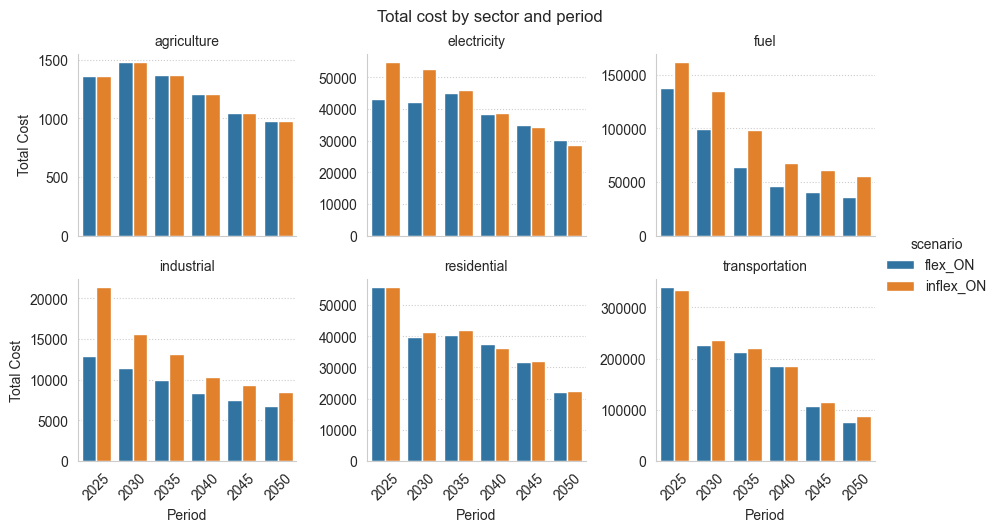

In [149]:
# prepare long-form dataframe for plotting
compare_long = compare_costs.melt(
    id_vars=['sector', 'period'],
    value_vars=['TotalCost_inflex_ON', 'TotalCost_flex_ON'],
    var_name='scenario',
    value_name='TotalCost'
)
compare_long['scenario'] = compare_long['scenario'].map({
    'TotalCost_inflex_ON': 'inflex_ON',
    'TotalCost_flex_ON': 'flex_ON'
})

# apply theme and plot
plt.rcParams.update(theme_dict)
palette = {'inflex_ON': '#ff7f0e', 'flex_ON': '#1f77b4'}

g = sns.catplot(
    data=compare_long,
    x='period',
    y='TotalCost',
    hue='scenario',
    col='sector',
    kind='bar',
    col_wrap=3,
    sharey=False,
    height=2.5,
    aspect=1.2,
    palette=palette,
    hue_order=['flex_ON', 'inflex_ON']
)

g.set_axis_labels('Period', 'Total Cost')
g.set_titles('{col_name}')
for ax in g.axes.flatten():
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

g.figure.suptitle('Total cost by sector and period', y=1.02)
g.savefig('../Documentation/docs/figures/total_costs_by_sector_period.png', dpi=300, bbox_inches='tight')
plt.show()

           sector  TotalCost_inflex_ON  TotalCost_flex_ON
0     agriculture         7.438022e+03       7.438017e+03
1     electricity         2.553326e+05       2.341921e+05
2            fuel         5.794204e+05       4.251325e+05
3      industrial         7.812011e+04       5.677032e+04
4     residential         2.299133e+05       2.276307e+05
5  transportation         1.178207e+06       1.147844e+06


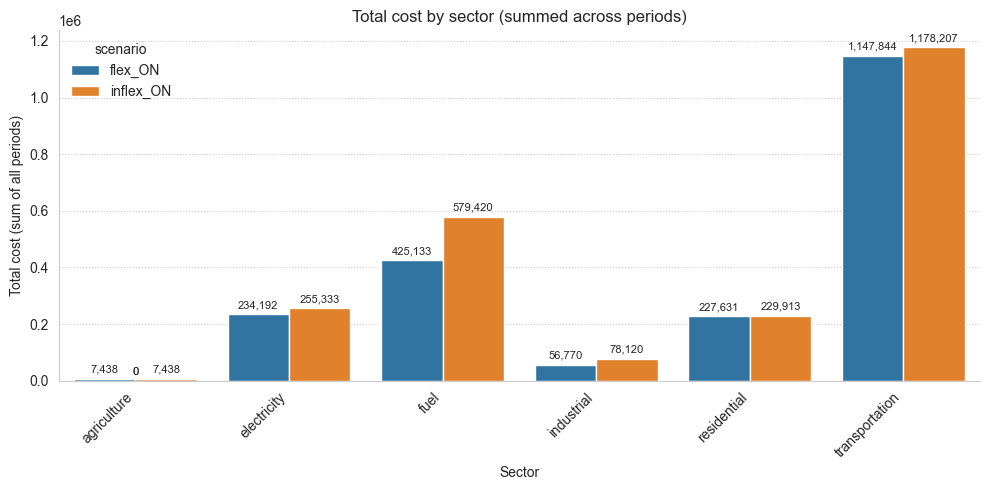

In [152]:
# aggregate total cost across all periods by sector and plot side-by-side bars for scenarios
sum_df = compare_costs.groupby('sector')[['TotalCost_inflex_ON', 'TotalCost_flex_ON']].sum().reset_index()
# sum_df['Cost change'] = sum_df['TotalCost_flex_ON'] - sum_df['TotalCost_inflex_ON']
# sum_df = sum_df[['sector', 'Cost change']]
print(sum_df)
# sum_df = sum_df.loc[sum_df['sector']!='agriculture'].copy()  # exclude agriculture for clarity

plot_df = sum_df.melt(
    id_vars='sector',
    value_vars=['TotalCost_inflex_ON', 'TotalCost_flex_ON'],
    var_name='scenario',
    value_name='TotalCost'
)
plot_df['scenario'] = plot_df['scenario'].map({
    'TotalCost_inflex_ON': 'inflex_ON',
    'TotalCost_flex_ON': 'flex_ON'
})

plt.rcParams.update(theme_dict)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x='sector',
    y='TotalCost',
    hue='scenario',
    hue_order=['flex_ON', 'inflex_ON'],
    palette=palette,
    ax=ax
)

ax.set_xlabel('Sector')
ax.set_ylabel('Total cost (sum of all periods)')
ax.set_title('Total cost by sector (summed across periods)')
plt.xticks(rotation=45, ha='right')


# annotate bars
for p in ax.patches:
    h = p.get_height()
    if not pd.isna(h):
        ax.annotate(f'{h:,.0f}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=8, rotation=0, xytext=(0, 3), textcoords='offset points')

fig.tight_layout()
fig.savefig('../Documentation/docs/figures/total_costs_by_sector_sum.png', dpi=300, bbox_inches='tight')
plt.show()

           sector    Cost change
0     agriculture       0.005195
1     electricity   21140.546490
2            fuel  154287.839421
3      industrial   21349.781424
4     residential    2282.635925
5  transportation   30363.053484


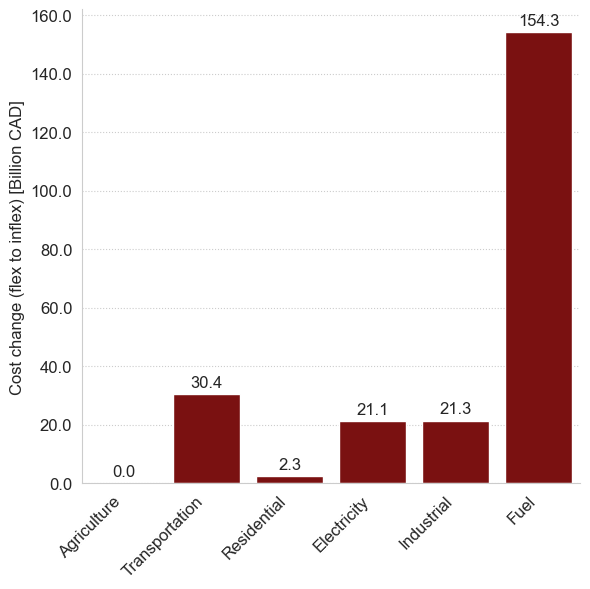

In [74]:
from matplotlib.ticker import FormatStrFormatter


# aggregate total cost across all periods by sector and plot side-by-side bars for scenarios
sum_df = compare_costs.groupby('sector')[['TotalCost_inflex_ON', 'TotalCost_flex_ON']].sum().reset_index()
sum_df['Cost change'] = sum_df['TotalCost_inflex_ON'] - sum_df['TotalCost_flex_ON']
sum_df = sum_df[['sector', 'Cost change']]

print(sum_df)

sum_df['Cost change'] = sum_df['Cost change'] / 1e3  # convert to B CAD
sum_df['sector'] = sum_df['sector'].str.capitalize()


plt.rcParams.update(theme_dict)
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(
    data=sum_df,
    x='sector',
    y='Cost change',
    ax=ax,
    order=[ 'Agriculture', 'Transportation','Residential', 'Electricity', 'Industrial','Fuel'],
    color='darkred'
)

ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Cost change (flex to inflex) [Billion CAD]', fontsize=12)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.yticks(fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)



# annotate bars
for p in ax.patches:
    h = p.get_height()
    
    if not pd.isna(h):
        if h > 0:
            ax.annotate(f'{h:,.1f}', (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=12, rotation=0, xytext=(0, 3), textcoords='offset points')
        else: 
            ax.annotate(f'{h:,.1f}', (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='top', fontsize=12, rotation=0, xytext=(0, -3), textcoords='offset points')

fig.tight_layout()
fig.savefig('../Documentation/docs/figures/total_costs_change_by_sector_sum.png', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
flowOut = data['OutputFlowOut'].copy()

df = flowOut.groupby(['period','tech','sector'],as_index=False)['flow'].sum().copy()
techs_imp = df.loc[df['tech'].str.contains('F_IMP_')]['tech'].unique()
fuels = []
for tech in techs_imp:
    fuels.append(tech.split('F_IMP_')[1])

cost_transfer = {}

fuels
for fuel in fuels:
    # print(f'\nFuel Import Technology: {fuel}\n')
    cost_transfer[fuel] = df.loc[df['tech'].str.contains(f'_{fuel}$', regex=True)]

cost_trans = {'fuel':[], 'period': [], 'sector':[], 'share':[]}

for fuel, df in cost_transfer.items():
    # print(f'\nFuel: {fuel}\n')
    fuel_df = df.loc[df['tech'] == f'F_IMP_{fuel}']
    sectors_df = df.loc[df['tech'] != f'F_IMP_{fuel}']
    # print(fuel_df.reset_index(drop=True))
    # print(sectors_df.reset_index(drop=True)) 
    for period in df['period'].unique():
        sector_period_df = sectors_df.loc[sectors_df['period'] == period]
        for sector in sector_period_df['sector'].unique():
            cost_trans['fuel'].append(fuel)
            cost_trans['period'].append(period)
            cost_trans['sector'].append(sector)
            cost_trans['share'].append(sector_period_df.loc[sector_period_df['sector'] == sector,'flow'].iloc[0]/sector_period_df['flow'].sum()) 
                                

In [127]:
costs

,scenario,region,sector,period,tech,vintage,d_invest,d_fixed,d_var,d_emiss,invest,fixed,var,emiss
0,zulu,ON,agriculture,2025,F_A_DSL,2025,0.000000,0.0,114.184235,0.0,0.000000,0.0,124.663248,0.0
1,zulu,ON,agriculture,2025,F_A_GSL,2025,0.000000,0.0,1113.542081,0.0,0.000000,0.0,1215.735019,0.0
2,zulu,ON,agriculture,2025,F_A_NG,2025,0.000000,0.0,132.250512,0.0,0.000000,0.0,144.387520,0.0
3,zulu,ON,agriculture,2030,F_A_DSL,2030,0.000000,0.0,416.842849,0.0,0.000000,0.0,527.582975,0.0
4,zulu,ON,agriculture,2030,F_A_GSL,2030,0.000000,0.0,956.024103,0.0,0.000000,0.0,1210.005260,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2279,zulu,ON,transportation,2050,T_MDV_T_DSL_N,2050,0.000112,0.0,0.000000,0.0,0.000257,0.0,0.000000,0.0
2280,zulu,ON,transportation,2050,T_MDV_T_DSL_PHEV_N,2050,0.000237,0.0,0.000000,0.0,0.000542,0.0,0.000000,0.0
2281,zulu,ON,transportation,2050,T_MDV_T_FCEV_N,2050,0.002099,0.0,0.003156,0.0,0.004799,0.0,0.007216,0.0
2282,zulu,ON,transportation,2050,T_MDV_T_FCHEV_N,2050,119.330819,0.0,159.832257,0.0,272.781889,0.0,365.365337,0.0


In [ ]:
costs = data['OutputCost']

costs_transfer = pd.DataFrame(cost_trans)
costs_transfer

print(costs_transfer)

for i in range(len(costs_transfer)):
    fuel_type = costs_transfer.loc[i,'fuel'] 
    period = costs_transfer.loc[i,'period']
    sector = costs_transfer.loc[i,'sector']
    share = costs_transfer.loc[i,'share']
    f = costs.loc[(costs['tech']==f'F_IMP_{fuel_type}')&(costs['period']==period)][['d_invest', 'd_fixed', 'd_var', 'd_emiss']]
    print(f.sum(axis=1))


df = costs.loc[costs['sector']=='fuel']
df['c_total'] = df.loc[:, ['d_invest', 'd_var', 'd_fixed', 'd_emiss']].sum(axis=1)
df = df.groupby(['period', 'tech'])['c_total'].sum()



      fuel  period          sector  share
0      CNG    2025  transportation    1.0
1      CNG    2030  transportation    1.0
2     COAL    2025      industrial    1.0
3     COAL    2030      industrial    1.0
4     COAL    2035      industrial    1.0
..     ...     ...             ...    ...
151  BIO_M    2035     electricity    1.0
152  BIO_M    2040     electricity    1.0
153  BIO_M    2045     electricity    1.0
154  BIO_M    2050     electricity    1.0
155    LNG    2050  transportation    1.0

[156 rows x 4 columns]
802    14.806544
dtype: float64
822    5.27813
dtype: float64
804    492.742375
dtype: float64
824    461.231321
dtype: float64
845    386.114912
dtype: float64
866    322.007576
dtype: float64
887    277.990591
dtype: float64
905    243.839192
dtype: float64
805    3357.314116
dtype: float64
825    3142.612668
dtype: float64
846    2630.804888
dtype: float64
867    2194.00772
dtype: float64
888    1894.096759
dtype: float64
906    1661.405239
dtype: float64
806    41

/var/folders/dg/njlqc4810y1dynp7nwp3qw180000gn/T/ipykernel_65829/806302656.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['c_total'] = df.loc[:, ['d_invest', 'd_var', 'd_fixed', 'd_emiss']].sum(axis=1)


period  tech       
2025    F_IMP_BIO_G      0.009455
        F_IMP_BIO_M      0.020093
        F_IMP_CNG       14.806544
        F_IMP_CO         0.048488
        F_IMP_COAL     492.742375
                          ...    
2050    F_IMP_PCOKE    252.808203
        F_IMP_RDSL     370.253429
        F_IMP_U_ENR      0.004396
        F_IMP_U_NAT    328.445707
        F_IMP_WOOD     486.278653
Name: c_total, Length: 120, dtype: float64

In [122]:
import numpy as np 


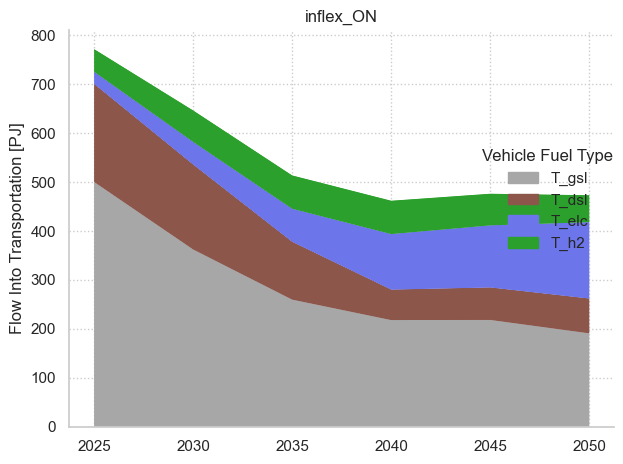

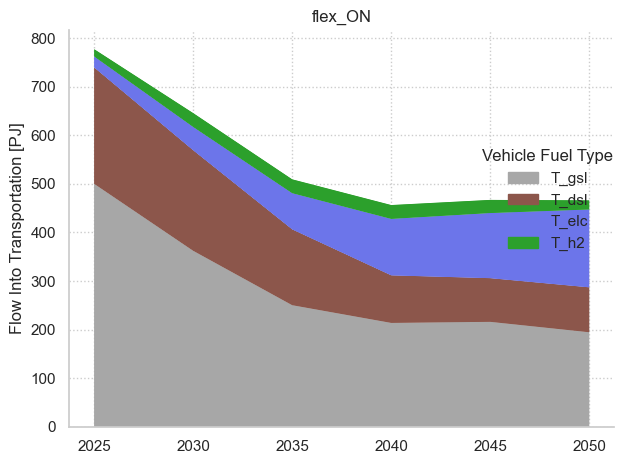

In [17]:
df_compare_flows = {}

# Status quo - Flex
flexibility = ['inflex_ON', 'flex_ON']  
for f in flexibility:
    db_path = f'outputs/{f}/canoe_ref.sqlite'
    data = mgmt.sqlite_to_dfs(db_path)

    
    df = data['OutputFlowOut'].copy()
    df = df.groupby(['output_comm', 'period'])['flow'].sum().reset_index()
    df_compare_flows[f] = df.copy()
    # df['capacity'] /= 1000 # convert to M units

    theme_dict = {
        **axes_style("whitegrid"),
        "grid.linestyle": ":",
        "legend.frameon": False,      # remove legend box
        "axes.spines.right": False,   # despine
        "axes.spines.top": False,
    }


    order = ['T_gsl', 'T_dsl', 'T_elc', 'T_h2']
    color_map = {'T_gsl': "#A7A7A7", 'T_elc': "#6c75ea", 'T_dsl': "#8c564b", 'T_h2': "#2ca02c"}


    df = df.loc[(df['output_comm'].isin(order))].copy()

    df["output_comm"] = pd.Categorical(df["output_comm"], categories=order, ordered=True)
    df = df.sort_values('output_comm')
    unit = 'k units'

    fig = (
        so.Plot(data=df, x='period', y='flow', color='output_comm')
        .add(so.Area(alpha=1), so.Agg(), so.Stack())
        .scale(color=so.Nominal(order=order, values=color_map))
        .label(y=f'Flow Into Transportation [PJ]', x='', title=f'{f}', color='Vehicle Fuel Type')
        .theme(theme_dict)
        .layout(engine="tight")
    )

    fig.save(f'../Documentation/docs/figures/FlowOut_{f}.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
    fig.show()


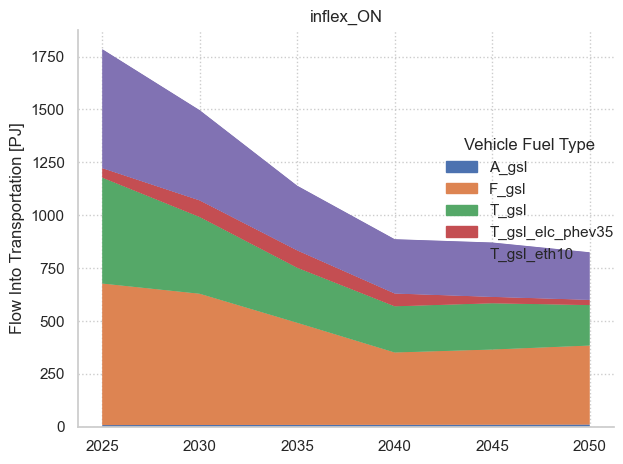

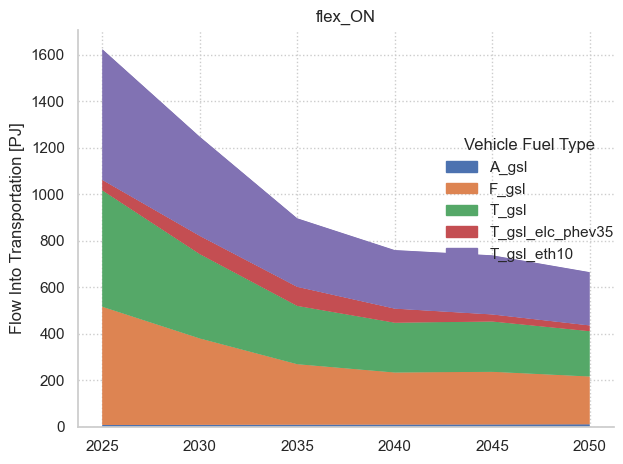

In [18]:
for f in flexibility: 
    df = df_compare_flows[f]
    df = df.loc[(df['output_comm'].str.contains('gsl'))].copy()
    
    fig = (
        so.Plot(data=df, x='period', y='flow', color='output_comm')
        .add(so.Area(alpha=1), so.Agg(), so.Stack())
        .label(y=f'Flow Into Transportation [PJ]', x='', title=f'{f}', color='Vehicle Fuel Type')
        .theme(theme_dict)
        .layout(engine="tight")
    )

    fig.save(f'../Documentation/docs/figures/FlowOut_gsl_{f}.png', dpi=300, bbox_inches='tight', pad_inches=0.15)
    fig.show()



In [1]:
# data = mgmt.sqlite_to_dfs('../data/canoe_dataset.sqlite')

# data